# Lab #03 - Task 2: Feature Scaling on Image Data (StandardScaler vs. MinMaxScaler)

## Objective & Requirements
In this task, we explore feature scaling techniques applied to image pixel data:
1. **Pixel Flattening**: Transform preprocessed image tensors $(N, 64, 64, 3)$ into 2D feature matrices $(N, 12288)$ for machine learning compatibility.
2. **MinMaxScaler (Normalization)**: Rescale pixel intensities to a fixed range $[0.0, 1.0]$.
3. **StandardScaler (Standardization)**: Center pixel distributions to zero mean ($\mu = 0$) with unit variance ($\sigma = 1$).
4. **Distribution Visualizations**: Compare histograms and KDE density distributions before and after scaling for individual channels and overall pixels.
5. **Theoretical Discussion**: Comprehensive analysis of when to use `MinMaxScaler` vs. `StandardScaler` in machine learning and computer vision.


### Step 1: Import Libraries & Prepare Image Feature Matrix
We load the preprocessed images from Task 1, inspect the raw integer range $[0, 255]$, and flatten each image into a feature vector of length $64 \times 64 \times 3 = 12,288$.


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Set styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Load and preprocess valid images (from Task 1)
dataset_dir = "dataset"
categories = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])
TARGET_SIZE = (64, 64)

images_list = []
labels_list = []

for cat in categories:
    files = glob.glob(os.path.join(dataset_dir, cat, "*.*"))
    for f in files:
        try:
            if os.path.getsize(f) == 0: continue
            with Image.open(f) as img:
                img.verify()
            with Image.open(f) as img:
                resized = img.convert('RGB').resize(TARGET_SIZE, Image.Resampling.BILINEAR)
                images_list.append(np.array(resized, dtype=np.uint8))
                labels_list.append(cat)
        except Exception:
            continue

X_images = np.array(images_list)
N, H, W, C = X_images.shape

# Flatten for Scikit-Learn (N_samples, H*W*C)
X_raw_flat = X_images.reshape(N, -1).astype(np.float64)

print(f"Loaded {N} images.")
print(f"Tensor Shape: {X_images.shape}")
print(f"Flattened 2D Feature Matrix Shape: {X_raw_flat.shape}")
print(f"Raw Pixels - Min: {X_raw_flat.min()}, Max: {X_raw_flat.max()}, Mean: {X_raw_flat.mean():.2f}, Std: {X_raw_flat.std():.2f}")


Loaded 17 images.
Tensor Shape: (17, 64, 64, 3)
Flattened 2D Feature Matrix Shape: (17, 12288)
Raw Pixels - Min: 0.0, Max: 255.0, Mean: 109.08, Std: 70.74


### Step 2: Normalization using `MinMaxScaler`
**Formula**:
$$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

- Maps raw $[0, 255]$ pixel values strictly into the bounded interval $[0.0, 1.0]$.
- Preserves relative zero distances and non-negativity.
- Commonly required as inputs to Neural Networks (CNNs) and gradient-based models.


In [2]:
# Apply MinMaxScaler
minmax_scaler = MinMaxScaler(feature_range=(0.0, 1.0))
X_minmax_flat = minmax_scaler.fit_transform(X_raw_flat)
X_minmax_images = X_minmax_flat.reshape(N, H, W, C)

print("--- MinMaxScaler (Normalized) Statistics ---")
print(f"Min: {X_minmax_flat.min():.4f}")
print(f"Max: {X_minmax_flat.max():.4f}")
print(f"Mean: {X_minmax_flat.mean():.4f}")
print(f"Std Dev: {X_minmax_flat.std():.4f}")


--- MinMaxScaler (Normalized) Statistics ---
Min: 0.0000
Max: 1.0000
Mean: 0.4661
Std Dev: 0.3146


### Step 3: Standardization using `StandardScaler` (Z-Score)
**Formula**:
$$Z = \frac{X - \mu}{\sigma}$$

- Centers the distribution around mean $\mu = 0$ with unit standard deviation $\sigma = 1$.
- Produces both positive and negative values.
- Crucial for distance-based algorithms (e.g., SVMs, PCA, KNN, Ridge/Lasso Regression) where features should have equal variance.


In [3]:
# Apply StandardScaler
standard_scaler = StandardScaler()
X_std_flat = standard_scaler.fit_transform(X_raw_flat)
X_std_images = X_std_flat.reshape(N, H, W, C)

print("--- StandardScaler (Standardized) Statistics ---")
print(f"Min: {X_std_flat.min():.4f}")
print(f"Max: {X_std_flat.max():.4f}")
print(f"Mean (across features): {X_std_flat.mean():.4e} (approx 0.0)")
print(f"Std Dev (across features): {X_std_flat.std():.4f} (approx 1.0)")


--- StandardScaler (Standardized) Statistics ---
Min: -2.4164
Max: 3.5508
Mean (across features): -8.7076e-18 (approx 0.0)
Std Dev (across features): 1.0000 (approx 1.0)


### Step 4: Visualizing Pixel-Value Distributions Before and After Scaling
Let's plot side-by-side Histograms and Kernel Density Estimation (KDE) curves comparing:
1. **Raw Pixel Intensities** ($0 - 255$)
2. **Min-Max Normalized Pixels** ($0.0 - 1.0$)
3. **Standardized Z-Score Pixels** (Mean = 0, Std = 1)


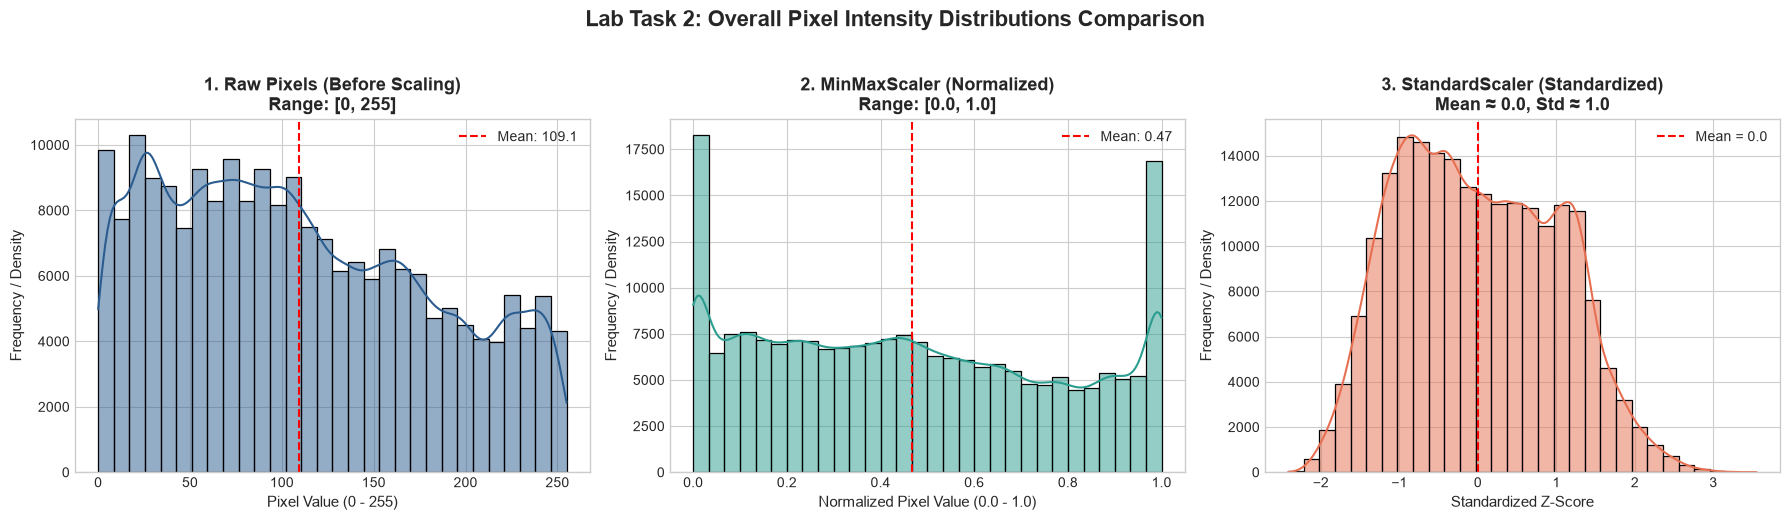

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Raw Distribution
sns.histplot(X_raw_flat.flatten(), kde=True, ax=axes[0], color='#2b5c8f', bins=30)
axes[0].set_title('1. Raw Pixels (Before Scaling)\nRange: [0, 255]', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pixel Value (0 - 255)', fontsize=11)
axes[0].set_ylabel('Frequency / Density', fontsize=11)
axes[0].axvline(X_raw_flat.mean(), color='red', linestyle='--', label=f"Mean: {X_raw_flat.mean():.1f}")
axes[0].legend()

# 2. MinMaxScaler Distribution
sns.histplot(X_minmax_flat.flatten(), kde=True, ax=axes[1], color='#2a9d8f', bins=30)
axes[1].set_title('2. MinMaxScaler (Normalized)\nRange: [0.0, 1.0]', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Normalized Pixel Value (0.0 - 1.0)', fontsize=11)
axes[1].set_ylabel('Frequency / Density', fontsize=11)
axes[1].axvline(X_minmax_flat.mean(), color='red', linestyle='--', label=f"Mean: {X_minmax_flat.mean():.2f}")
axes[1].legend()

# 3. StandardScaler Distribution
sns.histplot(X_std_flat.flatten(), kde=True, ax=axes[2], color='#e76f51', bins=30)
axes[2].set_title('3. StandardScaler (Standardized)\nMean ≈ 0.0, Std ≈ 1.0', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Standardized Z-Score', fontsize=11)
axes[2].set_ylabel('Frequency / Density', fontsize=11)
axes[2].axvline(0.0, color='red', linestyle='--', label="Mean = 0.0")
axes[2].legend()

plt.suptitle('Lab Task 2: Overall Pixel Intensity Distributions Comparison', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/task_02_pixel_distributions_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


### Step 5: Per-Channel (RGB) Distribution Breakdown
Images consist of Red, Green, and Blue color channels.
Below, we visualize how scaling affects each specific color channel independently.


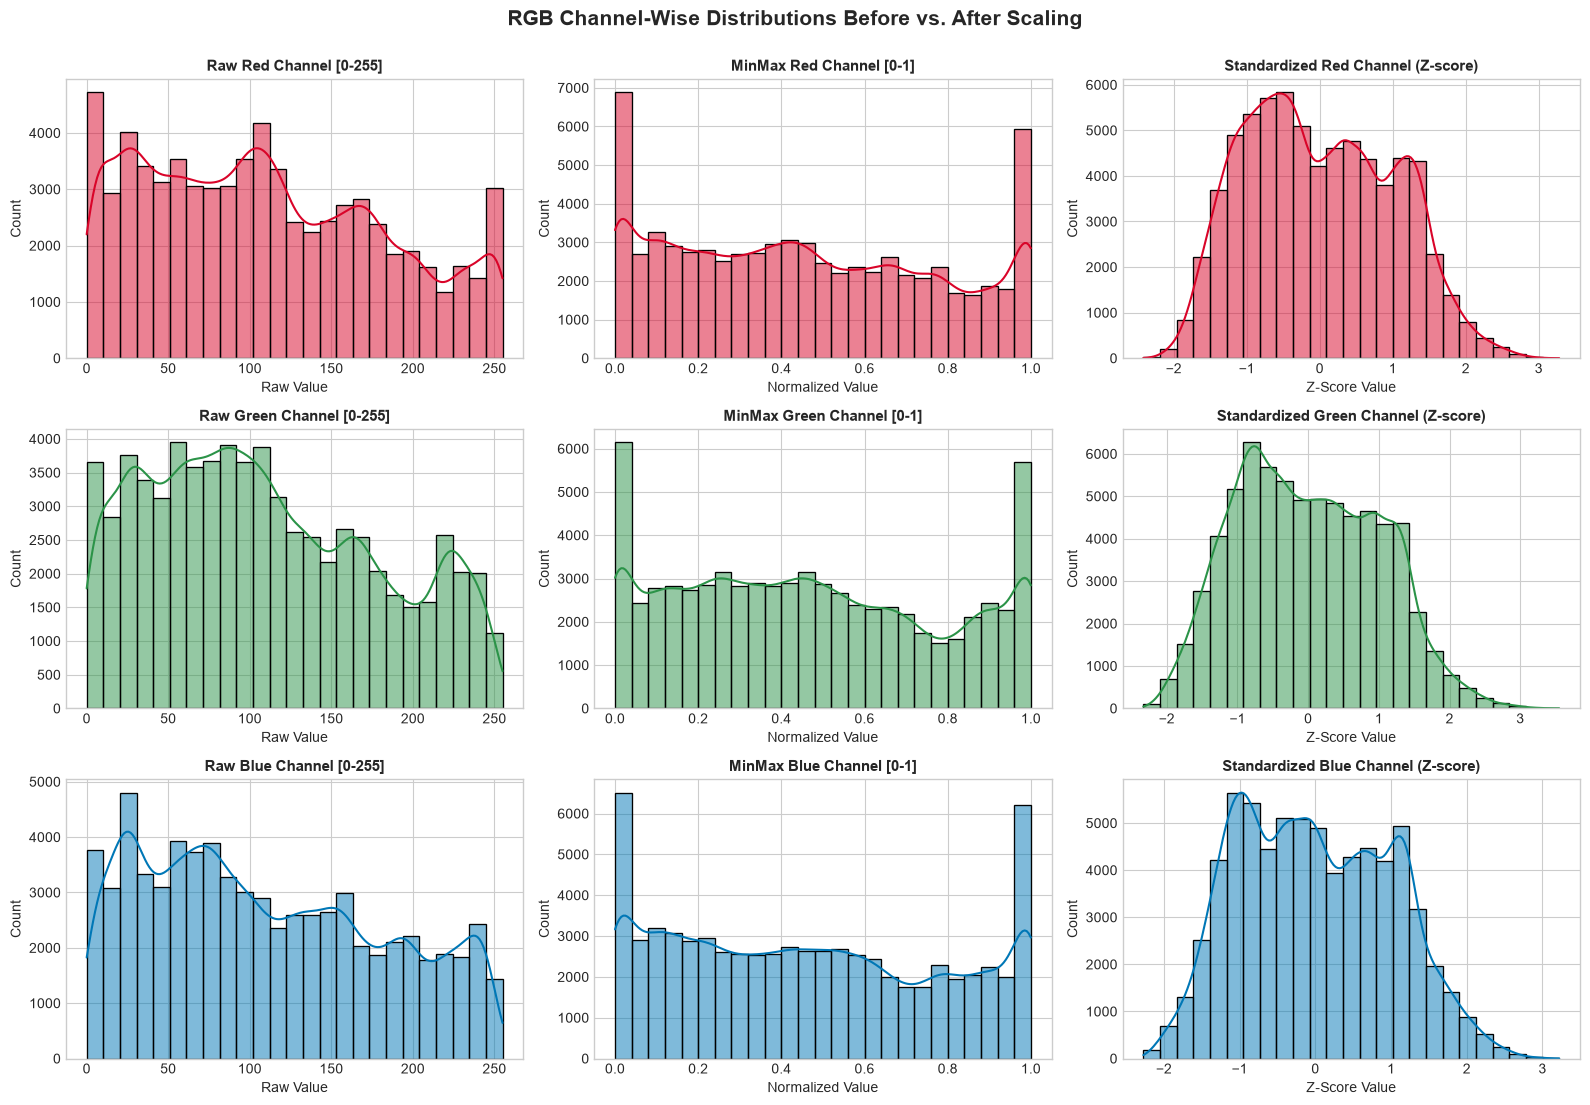

In [5]:
channel_names = ['Red Channel', 'Green Channel', 'Blue Channel']
channel_colors = ['#d90429', '#2b9348', '#0077b6']

fig, axes = plt.subplots(3, 3, figsize=(16, 11))

for c in range(3):
    # Raw Channel
    raw_c = X_images[:, :, :, c].flatten()
    sns.histplot(raw_c, kde=True, ax=axes[c, 0], color=channel_colors[c], bins=25)
    axes[c, 0].set_title(f'Raw {channel_names[c]} [0-255]', fontsize=11, fontweight='bold')
    axes[c, 0].set_xlabel('Raw Value')
    
    # MinMax Channel
    minmax_c = X_minmax_images[:, :, :, c].flatten()
    sns.histplot(minmax_c, kde=True, ax=axes[c, 1], color=channel_colors[c], bins=25)
    axes[c, 1].set_title(f'MinMax {channel_names[c]} [0-1]', fontsize=11, fontweight='bold')
    axes[c, 1].set_xlabel('Normalized Value')
    
    # StandardScaler Channel
    std_c = X_std_images[:, :, :, c].flatten()
    sns.histplot(std_c, kde=True, ax=axes[c, 2], color=channel_colors[c], bins=25)
    axes[c, 2].set_title(f'Standardized {channel_names[c]} (Z-score)', fontsize=11, fontweight='bold')
    axes[c, 2].set_xlabel('Z-Score Value')

plt.suptitle('RGB Channel-Wise Distributions Before vs. After Scaling', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('plots/task_02_rgb_channel_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


### Step 6: Visualizing Scaled Image Samples
Let's see what normalized vs. standardized image tensors look like when rendered:
*(Note: StandardScaler pixel values fall outside $[0, 1]$, so for visualization display they are clipped to $[0, 1]$).*


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.031847133757961776..1.0000000000000002].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000000000002].


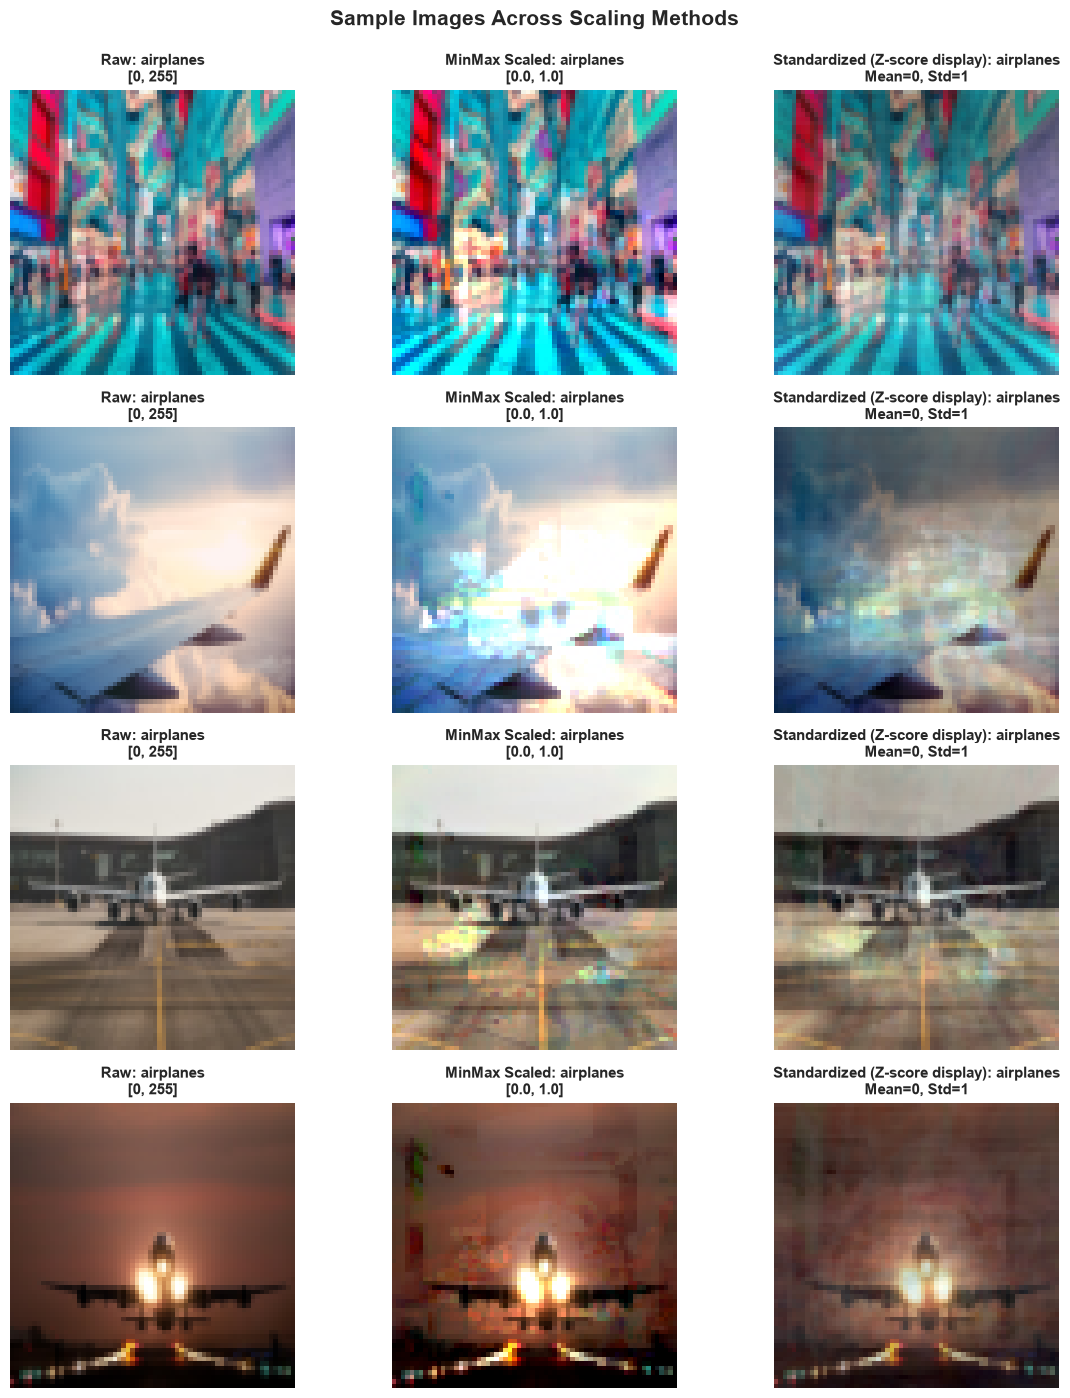

In [6]:
num_display = min(4, N)
fig, axes = plt.subplots(num_display, 3, figsize=(12, 3.5 * num_display))

for i in range(num_display):
    # 1. Raw Image
    axes[i, 0].imshow(X_images[i])
    axes[i, 0].set_title(f"Raw: {labels_list[i]}\n[0, 255]", fontsize=11, fontweight='bold')
    axes[i, 0].axis('off')
    
    # 2. MinMaxScaler Image
    axes[i, 1].imshow(X_minmax_images[i])
    axes[i, 1].set_title(f"MinMax Scaled: {labels_list[i]}\n[0.0, 1.0]", fontsize=11, fontweight='bold')
    axes[i, 1].axis('off')
    
    # 3. StandardScaler Clipped for Display
    std_display = (X_std_images[i] - X_std_images[i].min()) / (X_std_images[i].max() - X_std_images[i].min() + 1e-8)
    axes[i, 2].imshow(std_display)
    axes[i, 2].set_title(f"Standardized (Z-score display): {labels_list[i]}\nMean=0, Std=1", fontsize=11, fontweight='bold')
    axes[i, 2].axis('off')

plt.suptitle('Sample Images Across Scaling Methods', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('plots/task_02_scaled_images_samples.png', dpi=300, bbox_inches='tight')
plt.show()


### Step 7: In-Depth Discussion — When to Use `MinMaxScaler` vs. `StandardScaler`

| Feature Dimension | **`MinMaxScaler` (Normalization)** | **`StandardScaler` (Standardization)** |
| :--- | :--- | :--- |
| **Formula** | $X' = \frac{X - X_{min}}{X_{max} - X_{min}}$ | $Z = \frac{X - \mu}{\sigma}$ |
| **Output Range** | Strictly bounded in $[0, 1]$ (or custom range) | Unbounded, centered at $\mu=0$ with $\sigma=1$ |
| **Outlier Sensitivity** | **High**: Extreme outlier values compress all in-range features into a tiny band | **Moderate**: Outliers still affect mean and std, but no hard boundary compression |
| **Preserves Zero / Sparsity** | Yes (maps minimum to 0) | No (shifts zero to $-\mu/\sigma$, turns sparse data dense) |
| **Best Used When** | 1. Neural Networks & Deep Learning (CNNs, Vision Transformers) expecting bounded inputs.<br>2. Image generation models (GANs, Autoencoders) using Sigmoid ($[0,1]$) or Tanh ($[-1,1]$) output activations.<br>3. Algorithms that do not assume any specific probability distribution. | 1. Distance-based algorithms (K-Means, KNN, SVM with RBF kernel, PCA).<br>2. Linear models with regularization (Ridge, Lasso, Logistic Regression, Linear Regression) where features must share equal variance.<br>3. Data that follows a Gaussian / Normal bell curve distribution. |
| **Importance in Machine Learning** | Prevents large pixel values ($255$) from causing exploding gradients; ensures uniform learning rates across all RGB color channels. | Centers features to prevent gradient descent from oscillating wildly in anisotropic feature spaces. |
